In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/berka.db')

files = {
    'district': '../data/district.csv',
    'client':   '../data/client.csv',
    'account':  '../data/account.csv',
    'disp':     '../data/disp.csv',
    'loan':     '../data/loan.csv',
    'card':     '../data/card.csv',
    'order':    '../data/order.csv',
    'trans':    '../data/trans.csv',
}

for table, path in files.items():
    df = pd.read_csv(path, sep=';')
    df.to_sql(table, conn, if_exists='replace', index=False)
    print(f"{table}: {len(df)} rows inserted")

conn.close()
print("\nfiles have been loaded into the database.")

district: 77 rows inserted
client: 5369 rows inserted
account: 4500 rows inserted
disp: 5369 rows inserted
loan: 682 rows inserted
card: 892 rows inserted
order: 6471 rows inserted


/var/folders/z0/5xbc3shs20j2v_h622j6ghpc0000gn/T/ipykernel_31358/2853913539.py:18: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep=';')


trans: 1056320 rows inserted

files have been loaded into the database.


In [6]:
tables = ['district', 'client', 'account', 'disp', 'loan', 'card', 'order', 'trans']
conn = sqlite3.connect('../data/berka.db')
for t in tables:
    print(f"\n{'='*50}")
    print(f"table: {t}")
    df = pd.read_sql(f'SELECT * FROM "{t}" LIMIT 5', conn)
    print(df)


table: district
   A1           A2               A3       A4  A5  A6  A7  A8  A9    A10  \
0   1  Hl.m. Praha           Prague  1204953   0   0   0   1   1  100.0   
1   2      Benesov  central Bohemia    88884  80  26   6   2   5   46.7   
2   3       Beroun  central Bohemia    75232  55  26   4   1   5   41.7   
3   4       Kladno  central Bohemia   149893  63  29   6   2   6   67.4   
4   5        Kolin  central Bohemia    95616  65  30   4   1   6   51.4   

     A11   A12   A13  A14    A15    A16  
0  12541  0.29  0.43  167  85677  99107  
1   8507  1.67  1.85  132   2159   2674  
2   8980  1.95  2.21  111   2824   2813  
3   9753  4.64  5.05  109   5244   5892  
4   9307  3.85  4.43  118   2616   3040  

table: client
   client_id  birth_number  district_id
0          1        706213           18
1          2        450204            1
2          3        406009            1
3          4        561201            5
4          5        605703            5

table: account
   accoun

In [12]:
# reading the two key files for analysis
detail = pd.read_csv('../data/berka_balance_quartile.csv')
summary = pd.read_csv('../data/berka_segment_summary.csv')

# convert relevant columns to numeric, coercing errors to NaN
detail['balance'] = pd.to_numeric(detail['balance'], errors='coerce')
detail['is_bad'] = pd.to_numeric(detail['is_bad'], errors='coerce')
summary['churn_rate'] = pd.to_numeric(summary['churn_rate'], errors='coerce')
summary['retention_roi'] = pd.to_numeric(summary['retention_roi'], errors='coerce')

print('detail:', detail.columns.tolist())
print('summary:', summary.columns.tolist())

detail: ['account_id', 'region', 'balance', 'trans_count', 'balance_quartile', 'activity_quartile', 'loan_status', 'loan_amount', 'is_bad']
summary: ['region', 'segment', 'customer_cnt', 'avg_balance', 'avg_loan_amount', 'churn_rate', 'retention_roi']


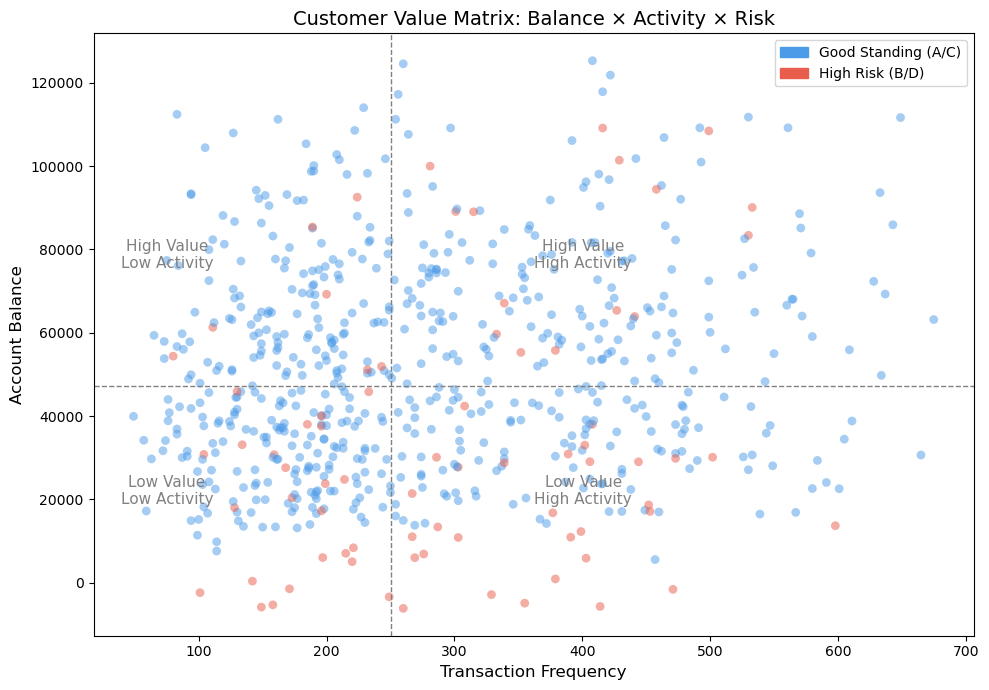

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 7))

# median values for balance and transaction count to define quadrants
balance_mid = detail['balance'].median()
activity_mid = detail['trans_count'].median()

# color mapping based on 'is_bad' status
colors = detail['is_bad'].map({0: '#4C9BE8', 1: '#E85D4C'})

ax.scatter(
    detail['trans_count'],
    detail['balance'],
    c=colors,
    alpha=0.5,
    s=40,
    edgecolors='none'
)

# axvline and axhline to draw the quadrant lines
ax.axvline(x=activity_mid, color='gray', linestyle='--', linewidth=1)
ax.axhline(y=balance_mid, color='gray', linestyle='--', linewidth=1)

# text annotations for each quadrant
ax.text(activity_mid * 0.3, balance_mid * 1.6, 'High Value\nLow Activity', fontsize=11, color='gray', ha='center')
ax.text(activity_mid * 1.6, balance_mid * 1.6, 'High Value\nHigh Activity', fontsize=11, color='gray', ha='center')
ax.text(activity_mid * 0.3, balance_mid * 0.4, 'Low Value\nLow Activity', fontsize=11, color='gray', ha='center')
ax.text(activity_mid * 1.6, balance_mid * 0.4, 'Low Value\nHigh Activity', fontsize=11, color='gray', ha='center')

# legend for good vs bad standing
good = mpatches.Patch(color='#4C9BE8', label='Good Standing (A/C)')
bad = mpatches.Patch(color='#E85D4C', label='High Risk (B/D)')
ax.legend(handles=[good, bad], loc='upper right')

ax.set_xlabel('Transaction Frequency', fontsize=12)
ax.set_ylabel('Account Balance', fontsize=12)
ax.set_title('Customer Value Matrix: Balance × Activity × Risk', fontsize=14)

plt.tight_layout()
plt.savefig('../output/customer_matrix.png', dpi=150)
plt.show()

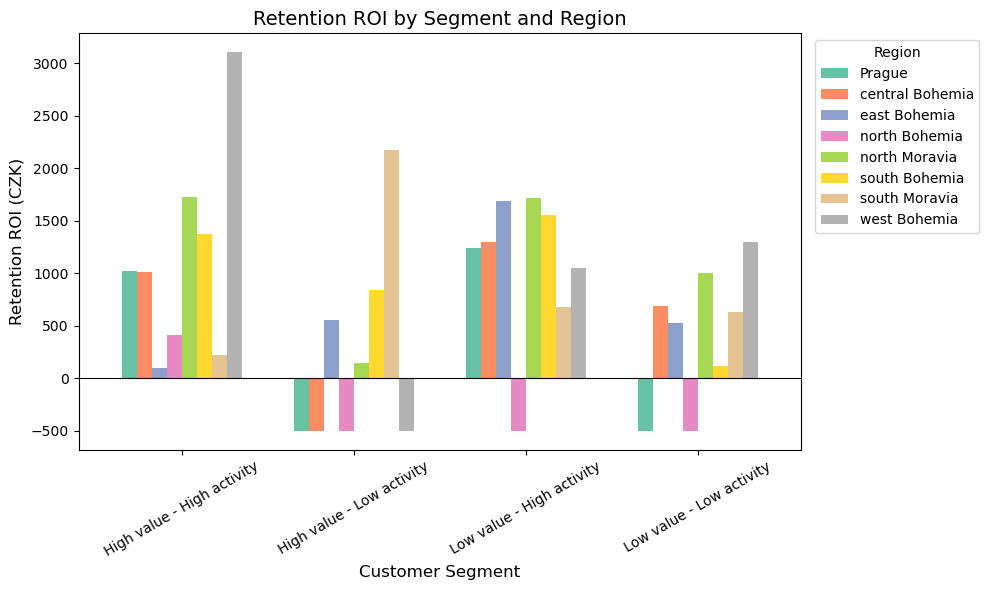

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

# postive ROI only, to focus on meaningful retention efforts
pivot = summary.pivot_table(
    index='segment', 
    columns='region', 
    values='retention_roi'
)

pivot.plot(kind='bar', ax=ax, colormap='Set2', width=0.7)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Customer Segment', fontsize=12)
ax.set_ylabel('Retention ROI (CZK)', fontsize=12)
ax.set_title('Retention ROI by Segment and Region', fontsize=14)
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../output/retention_roi.png', dpi=150)
plt.show()

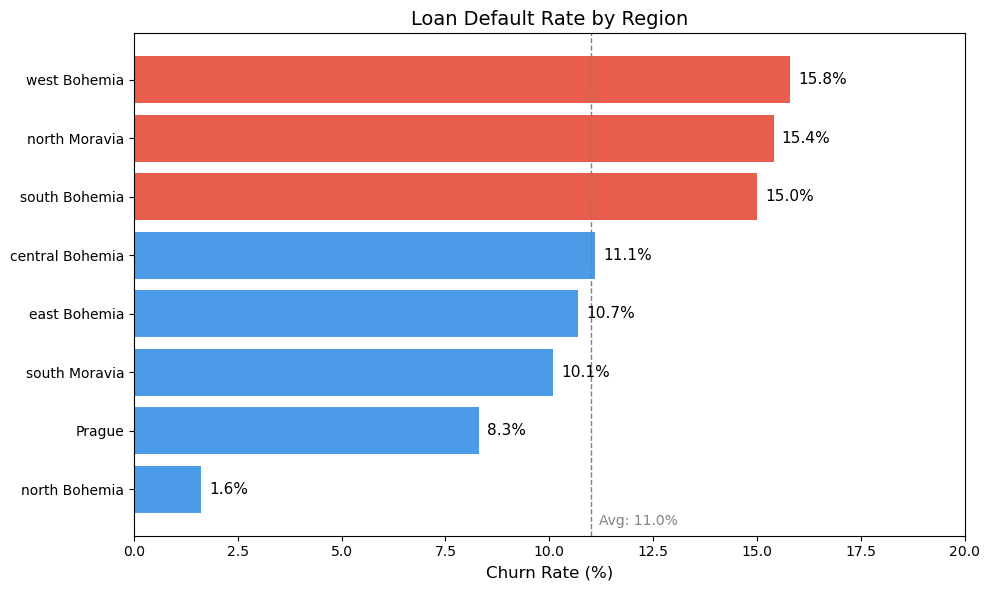

In [15]:
region_churn = pd.read_csv('../data/berka_region_churn.csv')

fig, ax = plt.subplots(figsize=(10, 6))

# rank by churn rate
region_churn = region_churn.sort_values('churn_rate', ascending=True)

bars = ax.barh(
    region_churn['region'],
    region_churn['churn_rate'],
    color=['#E85D4C' if x >= 12 else '#4C9BE8' for x in region_churn['churn_rate']],
    edgecolor='none'
)

# add value labels
for bar, val in zip(bars, region_churn['churn_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=11)

# average line
avg = region_churn['churn_rate'].mean()
ax.axvline(x=avg, color='gray', linestyle='--', linewidth=1)
ax.text(avg + 0.2, -0.6, f'Avg: {avg:.1f}%', color='gray', fontsize=10)

ax.set_xlabel('Churn Rate (%)', fontsize=12)
ax.set_title('Loan Default Rate by Region', fontsize=14)
ax.set_xlim(0, 20)

plt.tight_layout()
plt.savefig('../output/region_churn.png', dpi=150)
plt.show()